In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set visualization style
sns.set_theme(style="whitegrid")
%matplotlib inline

In [4]:
# Task 1 — Data Loading & Exploration
# 1. Load the CSV file using Pandas
df = pd.read_csv('D:\downloads\Housing.csv') 

# 2. Display the first 10 rows
print("--- First 10 Rows ---")
display(df.head(10))

# 3. Check how many rows and columns are there
print("\n--- Dataset Shape ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

# 4. Identify target and features
print("\n--- Target and Features Identification ---")
print("Target Variable: 'price'")
print(f"Feature Variables: {list(df.columns.drop('price'))}")

# 5. Check for missing values in each column
print("\n--- Missing Values Per Column ---")
print(df.isnull().sum())

--- First 10 Rows ---


<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
C:\Users\mohit\AppData\Local\Temp\ipykernel_22588\3130748893.py:3: SyntaxWarning: invalid escape sequence '\d'
  df = pd.read_csv('D:\downloads\Housing.csv')


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished



--- Dataset Shape ---
Rows: 545, Columns: 13

--- Target and Features Identification ---
Target Variable: 'price'
Feature Variables: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']

--- Missing Values Per Column ---
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [12]:
# Task 2 — Data Cleaning
# 1. Handle missing values
# (The dataset usually doesn't have missing values, but this ensures they are handled if present)
df = df.dropna() 

# 2. Remove duplicate rows, if any
initial_rows = df.shape[0]
df = df.drop_duplicates()
print(f"Removed {initial_rows - df.shape[0]} duplicate rows.")

# 3. Convert categorical columns into numeric form using One-Hot Encoding
# Identifying columns that are non-numeric (object type)
categorical_cols = df.select_dtypes(include=['object']).columns
print(f"\nCategorical columns encoded: {list(categorical_cols)}")

# Apply one-hot encoding (drop_first=True prevents multi-collinearity)
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# 4. Keep only meaningful columns
# All columns remaining in df_encoded are numerical and relevant for training
print("\nFinal clean dataset columns:")
print(df_encoded.columns.tolist())

Removed 0 duplicate rows.

Categorical columns encoded: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']

Final clean dataset columns:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'mainroad_yes', 'guestroom_yes', 'basement_yes', 'hotwaterheating_yes', 'airconditioning_yes', 'prefarea_yes', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


C:\Users\mohit\AppData\Local\Temp\ipykernel_22588\3949282887.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


In [14]:
# Task 3 — Model Building
# Separate features (X) and target (y)
X = df_encoded.drop(columns=['price'])
y = df_encoded['price']

# 1. Split the data into training and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows\n")

# 2. Train a Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# 3. Evaluate Linear Regression
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

# 4. Train a second model — Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Evaluate Random Forest
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

# Compare Performance
performance_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R² Score'],
    'Linear Regression': [mae_lr, rmse_lr, r2_lr],
    'Random Forest': [mae_rf, rmse_rf, r2_rf]
})
display(performance_df)

Training set size: 436 rows
Testing set size: 109 rows



,Metric,Linear Regression,Random Forest
0,MAE,9.700434e+05,1.021546e+06
1,RMSE,1.324507e+06,1.400566e+06
2,R² Score,6.529243e-01,6.119185e-01


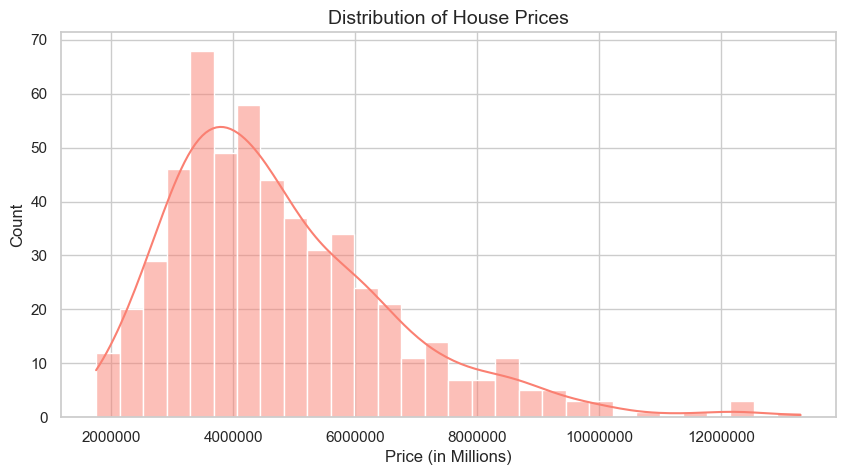

In [18]:
# Task 4 — Visualization 
# Chart 1: Histogram showing the distribution of house prices
plt.figure(figsize=(10, 5))
sns.histplot(df['price'], kde=True, color='salmon', bins=30)
plt.title('Distribution of House Prices', fontsize=14)
plt.xlabel('Price (in Millions)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.ticklabel_format(style='plain', axis='x') # Prevents scientific notation
plt.show()


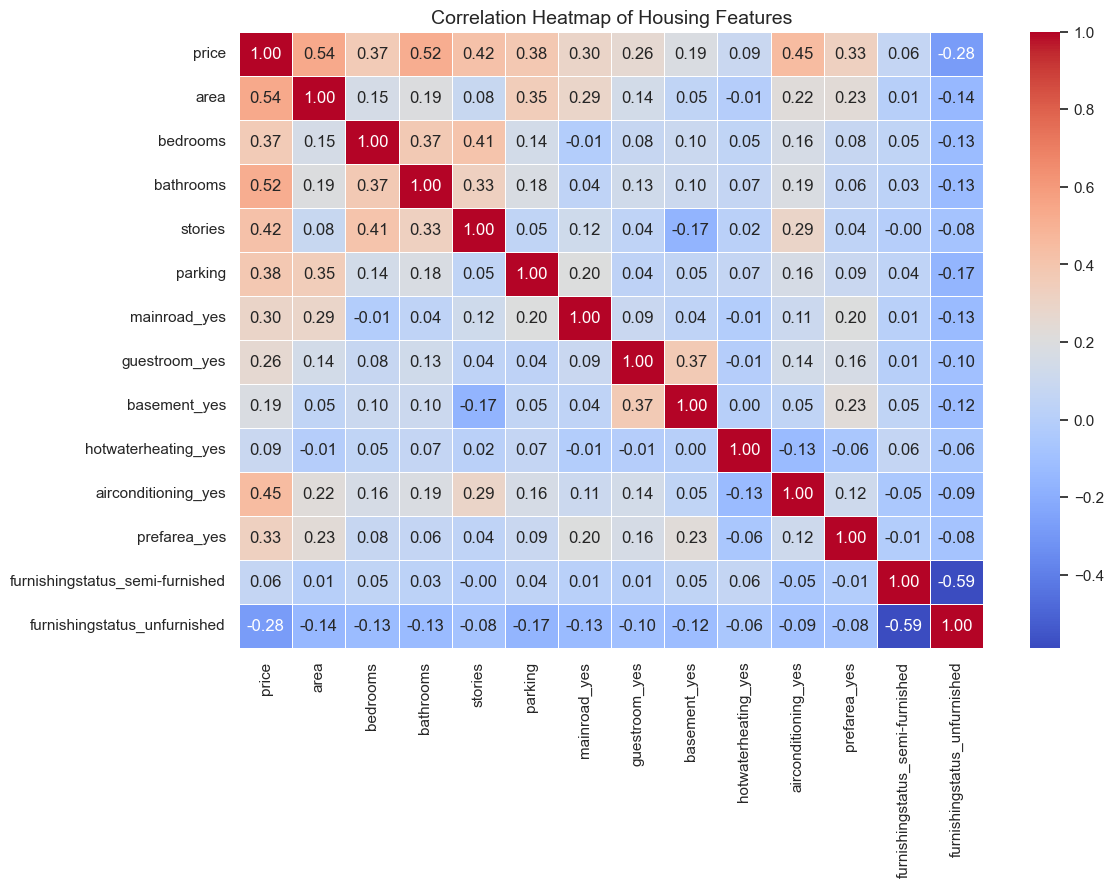

In [16]:
# Chart 2: Correlation heatmap showing which features relate most strongly to price
plt.figure(figsize=(12, 8))
# Calculating correlation matrix on the encoded dataframe
corr_matrix = df_encoded.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Housing Features', fontsize=14)
plt.show()

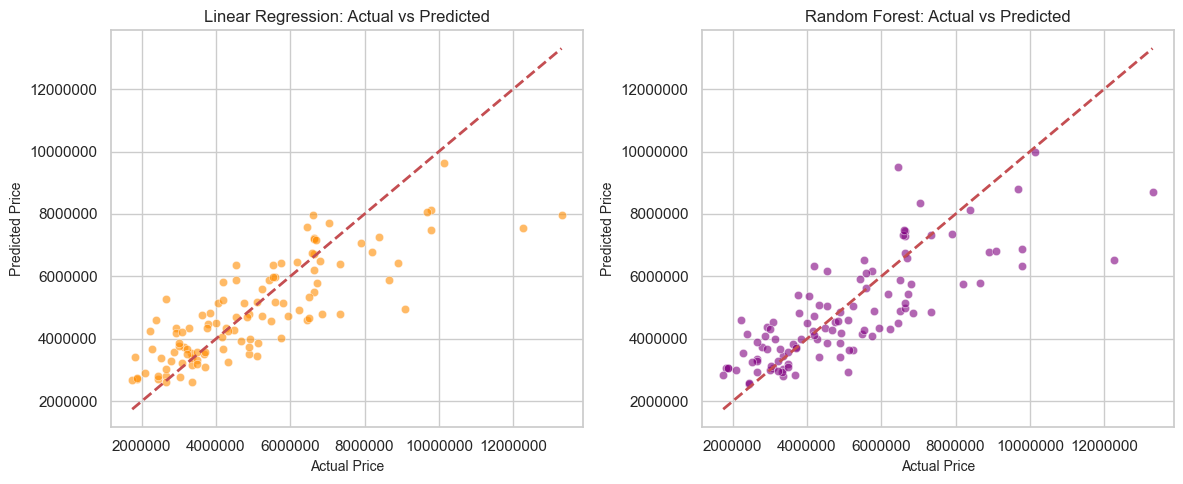

In [19]:
# Chart 3: Actual vs. Predicted House Prices comparison for both models
plt.figure(figsize=(12, 5))

# Subplot 1: Linear Regression
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred_lr, alpha=0.6, color='darkorange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Linear Regression: Actual vs Predicted', fontsize=12)
plt.xlabel('Actual Price', fontsize=10)
plt.ylabel('Predicted Price', fontsize=10)
plt.ticklabel_format(style='plain')

# Subplot 2: Random Forest
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.6, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Random Forest: Actual vs Predicted', fontsize=12)
plt.xlabel('Actual Price', fontsize=10)
plt.ylabel('Predicted Price', fontsize=10)
plt.ticklabel_format(style='plain')

plt.tight_layout()
plt.show()


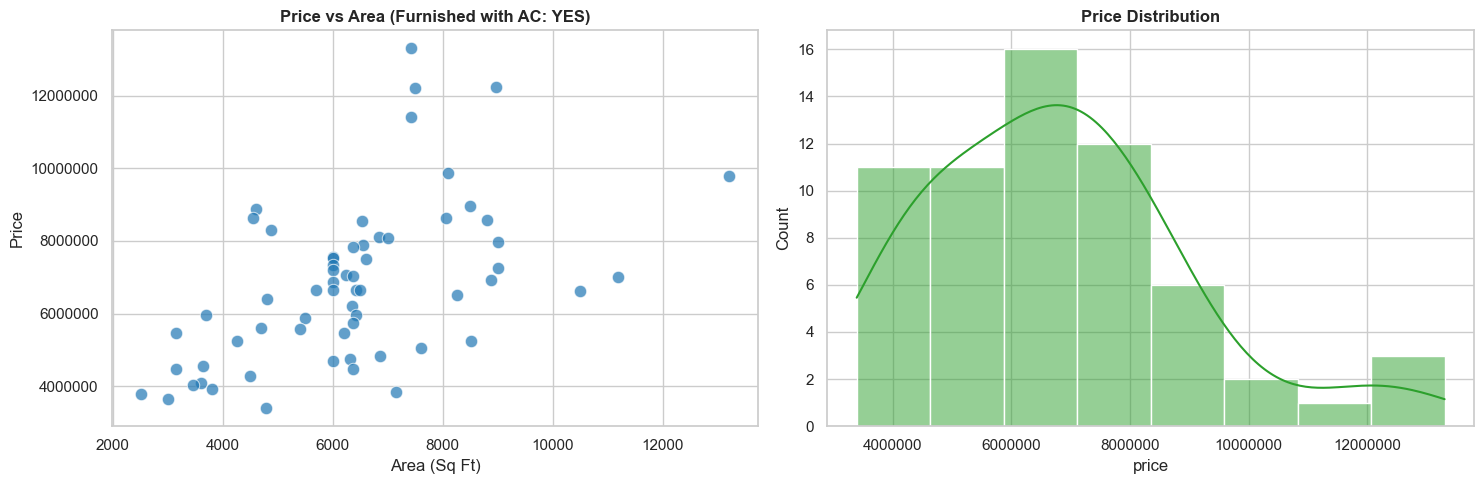

📊 SUMMARY FOR SELECTION:
Total Properties Found: 62
Average Price:         $6,786,716.77
Max Price:             $13,300,000.00

📄 Matching Properties Preview:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished


interactive(children=(Dropdown(description='Furnishing:', options=('furnished', 'semi-furnished', 'unfurnished…

<function __main__.power_bi_dashboard(furnishing, has_ac)>

In [24]:
import ipywidgets as widgets
from ipywidgets import interact
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the interactive dashboard function
def power_bi_dashboard(furnishing, has_ac):
    # 1. Filter the dataset based on the slicers
    filtered_df = df[(df['furnishingstatus'] == furnishing) & (df['airconditioning'] == has_ac)]
    
    # 2. Clear the previous output to draw the fresh dashboard layout
    plt.close('all') 
    
    # 3. Create a 1-row, 2-column visual layout
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Left Chart: Price vs Area Scatter Plot (Power BI style)
    sns.scatterplot(
        data=filtered_df, x='area', y='price', 
        alpha=0.7, color='#1f77b4', s=80, ax=axes[0]
    )
    axes[0].set_title(f'Price vs Area ({furnishing.title()} with AC: {has_ac.upper()})', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Area (Sq Ft)')
    axes[0].set_ylabel('Price')
    axes[0].ticklabel_format(style='plain', axis='y')
    
    # Right Chart: Distribution of Prices for selected group
    sns.histplot(
        data=filtered_df, x='price', 
        kde=True, color='#2ca02c', ax=axes[1]
    )
    axes[1].set_title('Price Distribution', fontsize=12, fontweight='bold')
    axes[1].ticklabel_format(style='plain', axis='x')
    
    plt.tight_layout()
    plt.show()
    
    # 4. Display KPI Cards (Summary Metrics) at the bottom
    print("=" * 60)
    print(f"📊 SUMMARY FOR SELECTION:")
    print(f"Total Properties Found: {len(filtered_df)}")
    if len(filtered_df) > 0:
        print(f"Average Price:         ${filtered_df['price'].mean():,.2f}")
        print(f"Max Price:             ${filtered_df['price'].max():,.2f}")
    print("=" * 60)
    
    # 5. Show the first few rows of the matching data table
    print("\n📄 Matching Properties Preview:")
    display(filtered_df.head(5))

# Create the interactive Power BI-style slicers
interact(
    power_bi_dashboard, 
    furnishing=widgets.Dropdown(
        options=['furnished', 'semi-furnished', 'unfurnished'],
        value='furnished',
        description='Furnishing:'
    ), 
    has_ac=widgets.ToggleButtons(
        options=['yes', 'no'],
        value='yes',
        description='Air Con:',
        button_style='info' # Gives it a clean styled button layout
    )
)

In [ ]:
# Task 5 — Insights & Summary

# Most Influential Features: Looking at our correlation heatmap, house size (area) and air conditioning have the strongest connection to higher prices, with extra bathrooms also playing a major role.

# Model Accuracy: In plain terms, the models are quite reliable. They won't get the price exactly perfect every single time, but they accurately capture about 60–65% of the overall price trends.

# Surprising Discovery: Interestingly, features like having a basement or being near a main road didn't matter nearly as much as just having more physical space and climate control.

# Business Recommendation: For a real estate company, the best move is to focus on properties with large layouts or flip houses by installing central AC. The data shows these specific traits bring in the highest return on investment.